In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
df1=pd.read_csv("Algerian_dataset_cleaned_final.csv")

In [13]:
df1.drop(['Unnamed: 0'],axis=1,inplace=True)

In [14]:
#Independent and dependent features
X=df1.drop('FWI',axis=1)
y=df1['FWI']

In [15]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
#Feature selection
df1.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

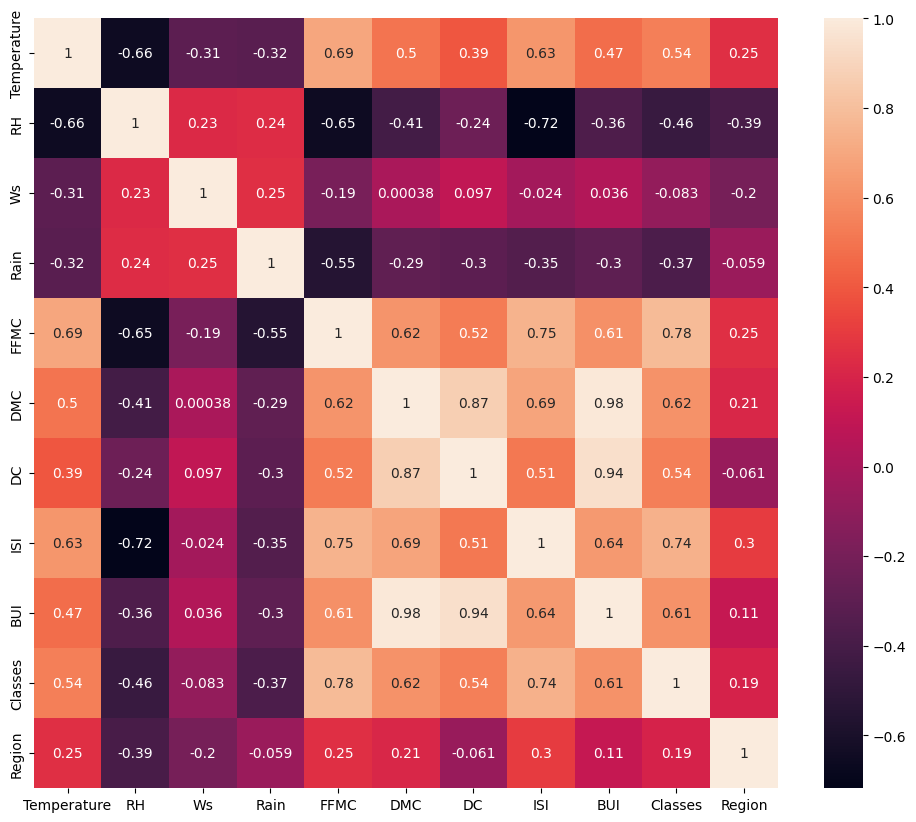

In [17]:
#Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [18]:
#Function to remove multicollinearity
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [19]:
#Threshold
c=correlation(X_train,0.85)
print(c)

{'BUI', 'DC'}


In [20]:
#Drop features with threshold with corr>0.85
X_train.drop(c,axis=1,inplace=True)
X_test.drop(c,axis=1,inplace=True)

In [21]:
X_train.shape, X_test.shape

((182, 9), (61, 9))

In [22]:
#Standardization
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

C:\Users\ARAVALI\AppData\Local\Temp\ipykernel_4796\361304999.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,2,1)


Text(0.5, 1.0, 'After Scaling')

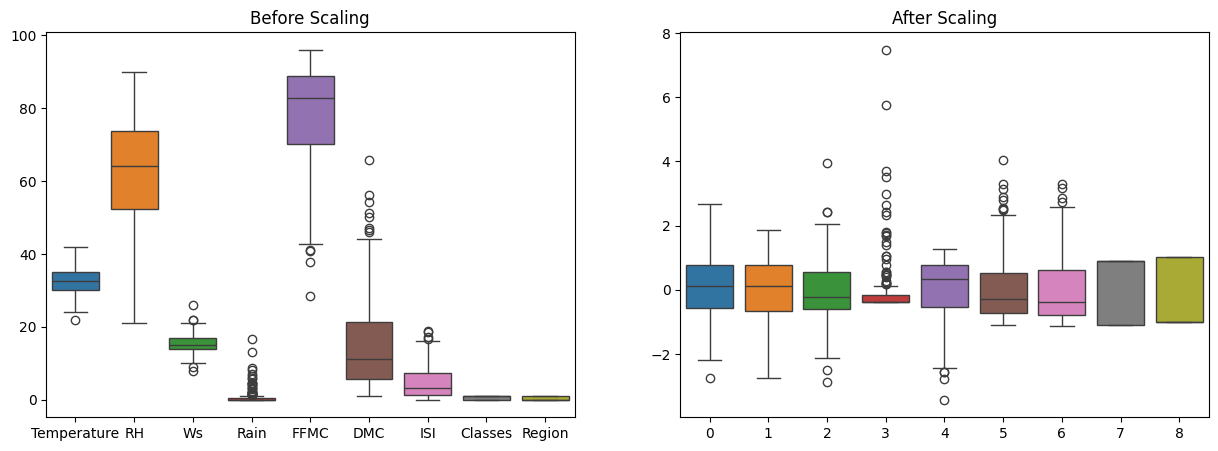

In [23]:
#Boxplot to understand effects of StandardScaler
plt.subplots(figsize= (15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('After Scaling')

0.5468236465249978 0.9847657384266951


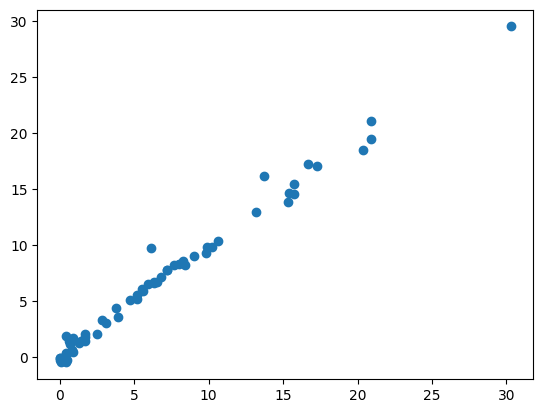

In [24]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(mae,score)
plt.scatter(y_test,y_pred) 

1.1331759949144087 0.9492020263112388


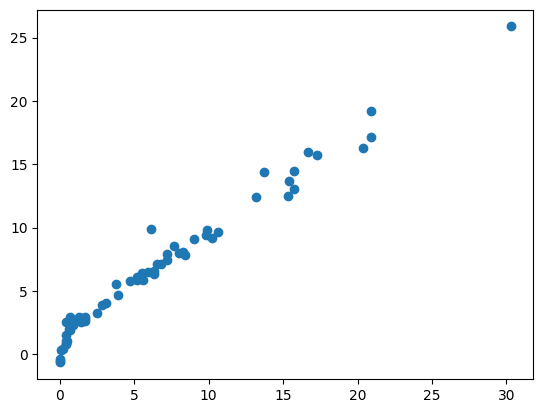

In [25]:
# Lasso Regression
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred_lasso=lasso.predict(X_test_scaled)
mae_1=mean_absolute_error(y_test,y_pred_lasso)
score_1=r2_score(y_test,y_pred_lasso)
print(mae_1,score_1)
plt.scatter(y_test,y_pred_lasso)

0.5642305340105715 0.9842993364555512


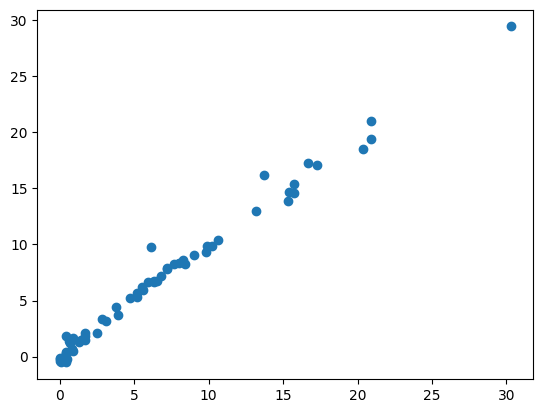

In [26]:
# Ridge Regression
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred_ridge=ridge.predict(X_test_scaled)
mae_2=mean_absolute_error(y_test,y_pred_ridge)
score_2=r2_score(y_test,y_pred_ridge)
print(mae_2,score_2)
plt.scatter(y_test,y_pred_ridge)

1.8822353634895999 0.8753460589519703


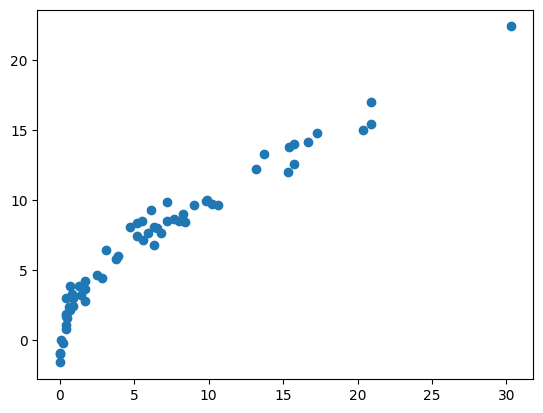

In [28]:
# ElasticNet Regression
from sklearn.linear_model import ElasticNet
elasticnet=ElasticNet()
elasticnet.fit(X_train_scaled,y_train)
y_pred_elasticnet=elasticnet.predict(X_test_scaled)
mae_6=mean_absolute_error(y_test,y_pred_elasticnet)
score_6=r2_score(y_test,y_pred_elasticnet)
print(mae_6,score_6)
plt.scatter(y_test,y_pred_elasticnet)

0.6358894638564663 0.9814406737205228


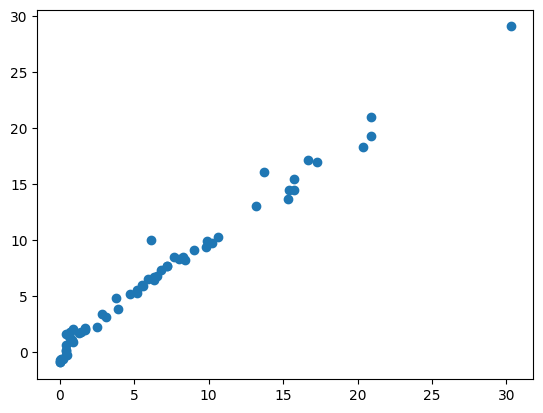

In [29]:
# Cross-validation Lasso
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
y_pred_lassocv=lassocv.predict(X_test_scaled)
mae_3=mean_absolute_error(y_test,y_pred_lassocv)
score_3=r2_score(y_test,y_pred_lassocv)
print(mae_3,score_3)
plt.scatter(y_test,y_pred_lassocv)

0.5642305340105715 0.9842993364555512


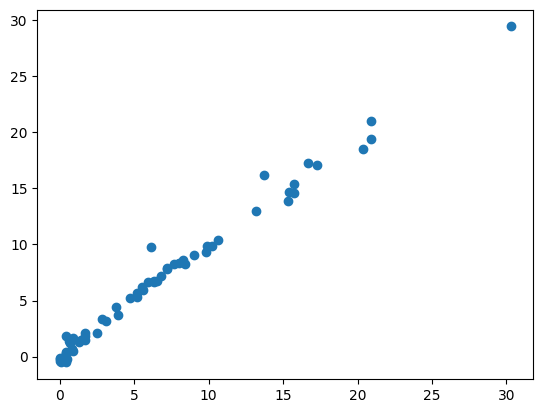

In [30]:
# Cross-validation Ridge
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred_ridgecv=ridgecv.predict(X_test_scaled)
mae_4=mean_absolute_error(y_test,y_pred_ridgecv)
score_4=r2_score(y_test,y_pred_ridgecv)
print(mae_4,score_4)
plt.scatter(y_test,y_pred_ridgecv)

0.6575946731430901 0.9814217587854941


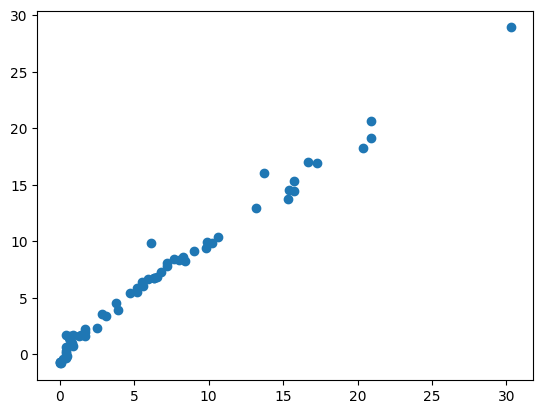

In [31]:
# Cross-validation ElasticNet
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled,y_train)
y_pred_elasticnetcv=elasticnetcv.predict(X_test_scaled)
mae_5=mean_absolute_error(y_test,y_pred_elasticnetcv)
score_5=r2_score(y_test,y_pred_elasticnetcv)
print(mae_5,score_5)
plt.scatter(y_test,y_pred_elasticnetcv)